In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any

import pandas as pd

METRICS_FILES = ("metrics.json", "metrics_ranking.json", "policy_metrics.json")
RUN_DIR_RE = re.compile(r"^(?P<timestamp>\d{8}T\d{6}Z)_(?P<rest>.+)$")
COLD_START_TASK_RE = re.compile(
    r"""
    ^(?P<dataset>.+?)
    _cold_start
    _k(?P<k>\d+)
    _cap(?P<total_items>\d+)
    (?:_eval_users(?P<eval_users>\d+)_cg(?P<groups_per_user>\d+))?
    _m(?P<m>\d+)
    _seed(?P<seed>\d+)$
    """,
    re.VERBOSE,
)

In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    for path in [start or Path.cwd(), *Path.cwd().parents]:
        if (path / "pyproject.toml").exists() and (path / "outputs").exists():
            return path
    raise RuntimeError("Could not find repo root with outputs/")


def read_json(path: Path) -> dict[str, Any]:
    return json.loads(path.read_text(encoding="utf-8"))


def resolve_dotted_path(payload: dict[str, Any], dotted: str) -> Any:
    cur: Any = payload
    for part in dotted.split("."):
        if not isinstance(cur, dict) or part not in cur:
            return None
        cur = cur[part]
    return cur


def flatten_metric_blocks(
    metrics: dict[str, Any],
    *,
    prefix: str = "",
) -> dict[str, Any]:
    """Flatten val/test metric dicts into scalar columns."""
    out: dict[str, Any] = {}
    for split in ("val", "test"):
        split_block = metrics.get(split)
        if not isinstance(split_block, dict):
            continue

        # Pointwise / ranking: macro_by_group, macro_by_user_group_mean, micro
        for group_name, group_vals in split_block.items():
            if not isinstance(group_vals, dict):
                # policy_ranking: test may be flat agreement metrics
                if isinstance(group_vals, (int, float, str, bool)) or group_vals is None:
                    key = f"{prefix}{split}.{group_name}" if prefix else f"{split}.{group_name}"
                    out[key] = group_vals
                continue
            for metric_name, value in group_vals.items():
                if isinstance(value, (int, float, str, bool)) or value is None:
                    key = (
                        f"{prefix}{split}.{group_name}.{metric_name}"
                        if prefix
                        else f"{split}.{group_name}.{metric_name}"
                    )
                    out[key] = value

    return out


def parse_cold_start_task_name_or_none(task: str | None) -> dict[str, Any] | None:
    if task is None:
        return None
    match = COLD_START_TASK_RE.match(str(task).strip())
    if match is None:
        return None
    groups = match.groupdict()
    return {
        "dataset": groups["dataset"],
        "k": int(groups["k"]),
        "m": int(groups["m"]),
        "seed": int(groups["seed"]),
        "total_items": int(groups["total_items"]),
        "eval_users": int(groups["eval_users"]) if groups["eval_users"] else None,
        "groups_per_user": int(groups["groups_per_user"]) if groups["groups_per_user"] else None,
    }


def parse_run_metadata(run_dir: Path, outputs_root: Path) -> dict[str, Any]:
    rel = run_dir.relative_to(outputs_root)
    parts = rel.parts
    suite = "/".join(parts[:-1]) if len(parts) > 1 else ""
    match = RUN_DIR_RE.match(run_dir.name)
    return {
        "suite": suite,
        "run_dir": str(rel),
        "run_name": run_dir.name,
        "timestamp": match.group("timestamp") if match else None,
    }


def metrics_row(
    *,
    run_dir: Path,
    outputs_root: Path,
    metrics_path: Path,
    metrics: dict[str, Any],
) -> dict[str, Any]:
    row = parse_run_metadata(run_dir, outputs_root)
    task_fields = parse_cold_start_task_name_or_none(metrics.get("task"))
    row.update(
        {
            "metrics_file": metrics_path.name,
            "metrics_kind": metrics_path.stem,  # metrics | metrics_ranking | policy_metrics
            "method": metrics.get("method"),
            "task": metrics.get("task"),
            "k": None if task_fields is None else task_fields["k"],
            "m": None if task_fields is None else task_fields["m"],
            "protocol": metrics.get("protocol"),
            "main_metric": metrics.get("main_metric"),
            "headline_value": resolve_dotted_path(metrics, str(metrics.get("main_metric", "")))
            if metrics.get("main_metric")
            else None,
            "threshold": metrics.get("threshold"),
            "llm_errors": metrics.get("llm_errors"),
            "requested_rows": metrics.get("requested_rows"),
            "scored_rows": metrics.get("scored_rows"),
        }
    )
    row.update(flatten_metric_blocks(metrics))
    return row


def collect_metrics_table(
    outputs_root: Path | str | None = None,
    *,
    latest_only: bool = True,
) -> pd.DataFrame:
    """
    Read all metrics artifacts under outputs/ and return one flat DataFrame.

    Parameters
    ----------
    outputs_root:
        Root outputs directory. Defaults to <repo>/outputs.
    latest_only:
        If True, keep only the newest timestamp per
        (suite, task, method, metrics_file).
    """
    root = Path(outputs_root) if outputs_root is not None else find_repo_root() / "outputs"
    rows: list[dict[str, Any]] = []

    for metrics_name in METRICS_FILES:
        for metrics_path in sorted(root.rglob(metrics_name)):
            run_dir = metrics_path.parent
            if not run_dir.is_dir():
                continue
            metrics = read_json(metrics_path)
            rows.append(
                metrics_row(
                    run_dir=run_dir,
                    outputs_root=root,
                    metrics_path=metrics_path,
                    metrics=metrics,
                )
            )

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows).sort_values(
        ["suite", "task", "method", "metrics_file", "timestamp"],
        na_position="last",
    )

    if latest_only:
        df = (
            df.drop_duplicates(
                ["suite", "task", "method", "metrics_file"],
                keep="last",
            )
            .reset_index(drop=True)
        )

    return df

In [3]:
df = collect_metrics_table()  # all suites under outputs/
display(df[["suite", "task", "k", "m", "method", "metrics_file", "main_metric", "headline_value"]].head())

# Cold start only
cold = df[df["suite"] == "in_distribution/cold_start"]

# Pointwise F1 headline
pointwise = df[df["metrics_file"] == "metrics.json"]
pointwise[["task", "k", "m", "method", "headline_value", "test.macro_by_user_group_mean.f1"]]

# Ranking NDCG@5 headline
ranking = df[df["metrics_file"] == "metrics_ranking.json"]
ranking[["task", "k", "m", "method", "headline_value", "test.macro_by_user_group_mean.ndcg@5"]]

,suite,task,k,m,method,metrics_file,main_metric,headline_value
0,in_distribution/cold_start,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,item_knn_cold_start,metrics.json,test.macro_by_user_group_mean.f1,0.095238
1,in_distribution/cold_start,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,item_knn_cold_start_ranking,metrics_ranking.json,test.macro_by_user_group_mean.ndcg@5,0.199671
2,in_distribution/cold_start,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,llm_yes_no_vllm_qwen36_27b_full,metrics.json,test.macro_by_user_group_mean.f1,0.109780
3,in_distribution/cold_start,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,llm_yes_no_vllm_qwen36_27b_full,metrics_ranking.json,test.macro_by_user_group_mean.ndcg@5,0.202134
4,in_distribution/cold_start,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,popularity_f1_threshold,metrics.json,test.macro_by_user_group_mean.f1,0.349393


,task,k,m,method,headline_value,test.macro_by_user_group_mean.ndcg@5
1,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,item_knn_cold_start_ranking,0.199671,0.199671
3,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,llm_yes_no_vllm_qwen36_27b_full,0.202134,0.202134
5,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,popularity_ranking,0.605332,0.605332
7,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,item_knn_cold_start_ranking,0.194555,0.194555
9,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,llm_yes_no_vllm_qwen36_27b_full,0.209000,0.209000
...,...,...,...,...,...,...
175,ml-1m_cold_start_k5_cap20_eval_users1000_cg5_m...,5,1,llm_yes_no_vllm_qwen36_27b_full,0.675215,0.675215
177,ml-1m_cold_start_k5_cap20_eval_users1000_cg5_m...,5,1,popularity_ranking,0.885172,0.885172
179,ml-1m_cold_start_k5_cap20_eval_users1000_cg5_m...,5,1,item_knn_cold_start_ranking,0.621159,0.621159
181,ml-1m_cold_start_k5_cap20_eval_users1000_cg5_m...,5,1,llm_yes_no_vllm_qwen36_27b_full,0.667321,0.667321


In [4]:
pointwise[["task", "k", "m", "method", "headline_value", "test.macro_by_user_group_mean.f1"]]

,task,k,m,method,headline_value,test.macro_by_user_group_mean.f1
0,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,item_knn_cold_start,0.095238,0.095238
2,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,llm_yes_no_vllm_qwen36_27b_full,0.109780,0.109780
4,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,popularity_f1_threshold,0.349393,0.349393
6,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,item_knn_cold_start,0.095238,0.095238
8,ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m...,1,19,llm_yes_no_vllm_qwen36_27b_full,0.115172,0.115172
...,...,...,...,...,...,...
174,ml-1m_cold_start_k5_cap20_eval_users1000_cg5_m...,5,1,llm_yes_no_vllm_qwen36_27b_full,0.619354,0.619354
176,ml-1m_cold_start_k5_cap20_eval_users1000_cg5_m...,5,1,popularity_f1_threshold,0.798553,0.798553
178,ml-1m_cold_start_k5_cap20_eval_users1000_cg5_m...,5,1,item_knn_cold_start,0.666667,0.666667
180,ml-1m_cold_start_k5_cap20_eval_users1000_cg5_m...,5,1,llm_yes_no_vllm_qwen36_27b_full,0.594183,0.594183


In [5]:
df["task"].tolist()

['ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed0',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed1',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed2',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed2',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed2',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed2',
 'ml-1m_cold_start_k1_cap20_eval_users1000_cg5_m19_seed2

In [6]:
import re

def parse_task_string(task_str):
    """
    Parses a task string like 'ml-1m_cold_start_k3_cap20_eval_users1000_cg5_m9_seed1'
    and extracts the k, m, and seed numbers as integers.

    Returns
    -------
    dict with keys 'k', 'm', 'seed', or None if not found.
    """
    pattern = r'_k(?P<k>\d+).*_m(?P<m>\d+).*_seed(?P<seed>\d+)'
    match = re.search(pattern, task_str)
    if match:
        return {
            "k": int(match.group("k")),
            "m": int(match.group("m")),
            "seed": int(match.group("seed")),
        }
    # Return None or raise, depending on desired behavior for bad inputs
    return None

# Example usage:
# parse_task_string('ml-1m_cold_start_k3_cap20_eval_users1000_cg5_m9_seed1')
# Output: {'k': 3, 'm': 9, 'seed': 1}

In [7]:
tasks = []
for i in df["task"].tolist():
    tasks.append(parse_task_string(i))

res_df = pd.DataFrame(tasks)
res_df.head()

,k,m,seed
0,1,19,0
1,1,19,0
2,1,19,0
3,1,19,0
4,1,19,0


In [8]:
res_df.groupby("k").count()

,m,seed
k,,
1,90,90
3,76,76
5,18,18


In [9]:
print('\n'.join(pointwise.columns.tolist()))

suite
run_dir
run_name
timestamp
metrics_file
metrics_kind
method
task
k
m
protocol
main_metric
headline_value
threshold
llm_errors
requested_rows
scored_rows
val.macro_by_group.accuracy
val.macro_by_group.f1
val.macro_by_group.n
val.macro_by_group.n_groups
val.macro_by_group.n_positive
val.macro_by_group.n_predicted_positive
val.macro_by_group.precision
val.macro_by_group.recall
val.macro_by_user_group_mean.accuracy
val.macro_by_user_group_mean.f1
val.macro_by_user_group_mean.n
val.macro_by_user_group_mean.n_groups
val.macro_by_user_group_mean.n_positive
val.macro_by_user_group_mean.n_predicted_positive
val.macro_by_user_group_mean.n_users
val.macro_by_user_group_mean.precision
val.macro_by_user_group_mean.recall
val.micro.accuracy
val.micro.f1
val.micro.n
val.micro.n_positive
val.micro.n_predicted_positive
val.micro.precision
val.micro.recall
test.macro_by_group.accuracy
test.macro_by_group.f1
test.macro_by_group.n
test.macro_by_group.n_groups
test.macro_by_group.n_positive
test.macr

In [10]:
[i for i in pointwise.columns.tolist() if "accuracy" in i]

['val.macro_by_group.accuracy',
 'val.macro_by_user_group_mean.accuracy',
 'val.micro.accuracy',
 'test.macro_by_group.accuracy',
 'test.macro_by_user_group_mean.accuracy',
 'test.micro.accuracy']

In [11]:
pointwise[["k", "m", "method", "test.macro_by_user_group_mean.accuracy", "test.macro_by_user_group_mean.f1"]]

,k,m,method,test.macro_by_user_group_mean.accuracy,test.macro_by_user_group_mean.f1
0,1,19,item_knn_cold_start,0.050000,0.095238
2,1,19,llm_yes_no_vllm_qwen36_27b_full,0.752050,0.109780
4,1,19,popularity_f1_threshold,0.912020,0.349393
6,1,19,item_knn_cold_start,0.050000,0.095238
8,1,19,llm_yes_no_vllm_qwen36_27b_full,0.757580,0.115172
...,...,...,...,...,...
174,5,1,llm_yes_no_vllm_qwen36_27b_full,0.667311,0.619354
176,5,1,popularity_f1_threshold,0.781291,0.798553
178,5,1,item_knn_cold_start,0.500000,0.666667
180,5,1,llm_yes_no_vllm_qwen36_27b_full,0.657226,0.594183


In [12]:
def make_mean_std_pivot(
    pointwise: pd.DataFrame,
    value_col: str = "test.macro_by_user_group_mean.accuracy"
):
    """
    Return a pivot table of mean±std per (k, m, method) and count. 
    
    Args:
        pointwise: DataFrame with columns ['k', 'm', 'method', value_col]
        value_col: The metric column to aggregate (default: test.macro_by_user_group_mean.accuracy)
    
    Returns:
        pivot_table: pd.DataFrame, index (k, m), columns=method, values=mean±std (as string)
        pivot_table_count: pd.DataFrame, index (k, m), columns=method, values=count (int)
    """
    group = (
        pointwise[["k", "m", "method", value_col]]
        .groupby(["k", "m", "method"])[value_col]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )

    def format_mean_std(row):
        if pd.isnull(row['std']):
            return f"{row['mean']:.6f}"
        return f"{row['mean']:.6f} ± {row['std']:.6f}"

    group["mean_std"] = group.apply(format_mean_std, axis=1)

    pivot_table = group.pivot(index=["k", "m"], columns="method", values="mean_std")
    pivot_table_count = group.pivot(index=["k", "m"], columns="method", values="count")

    # Optionally, add a count column for a specific method (or just return both tables)
    # Example: merging count for 'item_knn_cold_start'
    count_col_name = "item_knn_cold_start"
    if count_col_name in pivot_table_count.columns:
        merged = pivot_table.merge(
            pivot_table_count[[count_col_name]].rename(
                columns={count_col_name: "count"}
            ),
            left_index=True, right_index=True
        )
        return merged
    else:
        return pivot_table

# Example usage:
# make_mean_std_pivot(pointwise, "test.macro_by_user_group_mean.accuracy")

In [13]:
"""
Drop-in companion to make_mean_std_pivot(). Produces small-multiple line plots
that isolate the k-effect (history length) and the m-effect (negative-sampling
ratio / task difficulty) for each method.

Usage:
    from plot_k_m_effects import prepare_agg, plot_k_effect, plot_m_effect

    agg = prepare_agg(pointwise, "test.macro_by_user_group_mean.accuracy")
    fig1 = plot_k_effect(agg)   # x = k, one panel per m
    fig2 = plot_m_effect(agg)   # x = m, one panel per k
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def prepare_agg(pointwise: pd.DataFrame,
                 value_col: str = "test.macro_by_user_group_mean.accuracy") -> pd.DataFrame:
    """Same grouping as make_mean_std_pivot, but kept numeric (no string formatting)
    so it can be plotted directly."""
    agg = (
        pointwise[["k", "m", "method", value_col]]
        .groupby(["k", "m", "method"])[value_col]
        .agg(mean="mean", std="std", count="count")
        .reset_index()
    )
    agg["std"] = agg["std"].fillna(0.0)
    agg["sem"] = agg["std"] / np.sqrt(agg["count"])
    return agg


def plot_effect(agg: pd.DataFrame, facet_var: str, x_var: str,
                 err: str = "std", log_x: bool = False,
                 methods=None, title: str = None,
                 ylabel: str = "accuracy") -> plt.Figure:
    """
    One subplot per value of `facet_var` (held fixed), x-axis = `x_var` (swept),
    one line per method, shaded band = `err` (std or sem).
    """
    methods = methods or sorted(agg["method"].unique())
    facet_vals = sorted(agg[facet_var].unique())
    fig, axes = plt.subplots(1, len(facet_vals),
                              figsize=(4.2 * len(facet_vals), 3.6), sharey=True)
    axes = [axes] if len(facet_vals) == 1 else list(axes)

    for ax, fv in zip(axes, facet_vals):
        sub = agg[agg[facet_var] == fv]
        for method in methods:
            ms = sub[sub["method"] == method].sort_values(x_var)
            if ms.empty:
                continue
            ax.plot(ms[x_var], ms["mean"], marker="o", linewidth=2, label=method)
            ax.fill_between(ms[x_var], ms["mean"] - ms[err], ms["mean"] + ms[err], alpha=0.15)
        ax.set_title(f"{facet_var} = {fv}")
        ax.set_xlabel(x_var)
        if log_x:
            ax.set_xscale("log")
        xt = sorted(sub[x_var].unique())
        ax.set_xticks(xt)
        ax.set_xticklabels(xt)
        ax.grid(alpha=0.3)
    axes[0].set_ylabel(ylabel)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(methods),
               bbox_to_anchor=(0.5, 1.12), frameon=False)
    if title:
        fig.suptitle(title, y=1.22, fontsize=11)
    fig.tight_layout()
    return fig


def plot_k_effect(agg: pd.DataFrame, **kwargs) -> plt.Figure:
    """How does performance change as more history (k) is added?
    One panel per m, so the difficulty level is held fixed while k varies."""
    return plot_effect(agg, facet_var="m", x_var="k",
                        title="Effect of session history length (k), by m", **kwargs)


def plot_m_effect(agg: pd.DataFrame, **kwargs) -> plt.Figure:
    """How does performance change as more negatives (m) are added?
    One panel per k, so history length is held fixed while difficulty varies."""
    return plot_effect(agg, facet_var="k", x_var="m", log_x=True,
                        title="Effect of negative-sampling ratio (m), by k", **kwargs)


# ---------------------------------------------------------------------------
# Quick alternative if you just want something fast and don't need custom
# error bands / styling — seaborn does the faceting for you in one call:
#
#   import seaborn as sns
#   sns.relplot(data=agg, x="k", y="mean", hue="method", col="m",
#               kind="line", marker="o", facet_kws={"sharey": True})
#   sns.relplot(data=agg, x="m", y="mean", hue="method", col="k",
#               kind="line", marker="o", facet_kws={"sharey": True})
# ---------------------------------------------------------------------------

In [14]:
import seaborn as sns

def plot_rel_by_k_and_m(df, metric_col):
    agg = prepare_agg(df, metric_col)
    g = sns.relplot(
        data=agg, x="k", y="mean", hue="method", col="m",
        kind="line", marker="o", facet_kws={"sharey": True}
    )
    for ax in g.axes.flat:
        if ax.get_xlabel() == "k":
            data_x = agg["k"].unique()
            ax.set_xticks(sorted(data_x))
            ax.set_xticklabels([str(x) for x in sorted(data_x)])

    g = sns.relplot(
        data=agg, x="m", y="mean", hue="method", col="k",
        kind="line", marker="o", facet_kws={"sharey": True}
    )
    for ax in g.axes.flat:
        if ax.get_xlabel() == "m":
            data_x = agg["m"].unique()
            ax.set_xticks(sorted(data_x))
            ax.set_xticklabels([str(x) for x in sorted(data_x)])

# Example usage:
# plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.ndcg@10")
   

In [15]:
make_mean_std_pivot(pointwise, "test.macro_by_user_group_mean.accuracy")

method  item_knn_cold_start llm_yes_no_vllm_qwen36_27b_full  \
k m                                                           
1 1     0.500000 ± 0.000000             0.561623 ± 0.005551   
  2     0.333333 ± 0.000000             0.634657 ± 0.008563   
  3     0.250000 ± 0.000000             0.671552 ± 0.005983   
  9     0.100000 ± 0.000000             0.733489 ± 0.003111   
  19    0.050000 ± 0.000000             0.756180 ± 0.003638   
3 1     0.500000 ± 0.000000             0.638469 ± 0.004733   
  2     0.333333 ± 0.000000             0.659306 ± 0.004654   
  3     0.250000 ± 0.000000             0.666707 ± 0.004896   
  9     0.100000 ± 0.000000             0.681186 ± 0.001691   
  19               0.946470                             NaN   
5 1     0.500000 ± 0.000000             0.662981 ± 0.005191   

method popularity_f1_threshold  count  
k m                                    
1 1        0.773846 ± 0.015042    3.0  
  2        0.776426 ± 0.007785    3.0  
  3        0.800809 ± 0.009048    3.0  
  9        0.876326 ± 0.010259    3.0  
  19       0.913250 ± 0.005430    3.0  
3 1        0.773777 ± 0.014406    3.0  
  2        0.784103 ± 0.014566    3.0  
  3        0.798999 ± 0.013543    3.0  
  9        0.870071 ± 0.008847    3.0  
  19                  0.912930    1.0  
5 1        0.774169 ± 0.014978    3.0

In [16]:
make_mean_std_pivot(pointwise, "test.macro_by_user_group_mean.f1").reset_index()

method,k,m,item_knn_cold_start,llm_yes_no_vllm_qwen36_27b_full,popularity_f1_threshold,count
0,1,1,0.666667 ± 0.000000,0.362737 ± 0.010726,0.796568 ± 0.006331,3.0
1,1,2,0.500000 ± 0.000000,0.331221 ± 0.004699,0.707451 ± 0.007283,3.0
2,1,3,0.400000 ± 0.000000,0.290642 ± 0.005481,0.651187 ± 0.010936,3.0
3,1,9,0.181818 ± 0.000000,0.179063 ± 0.002250,0.491482 ± 0.012298,3.0
4,1,19,0.095238 ± 0.000000,0.112236 ± 0.002728,0.375930 ± 0.022999,3.0
5,3,1,0.666667 ± 0.000000,0.555837 ± 0.009131,0.795967 ± 0.006487,3.0
6,3,2,0.500000 ± 0.000000,0.486196 ± 0.005922,0.711340 ± 0.004021,3.0
7,3,3,0.400000 ± 0.000000,0.422341 ± 0.001756,0.652715 ± 0.008638,3.0
8,3,9,0.181818 ± 0.000000,0.251397 ± 0.003847,0.492009 ± 0.007528,3.0
9,3,19,0.132260,NaN,0.358824,1.0


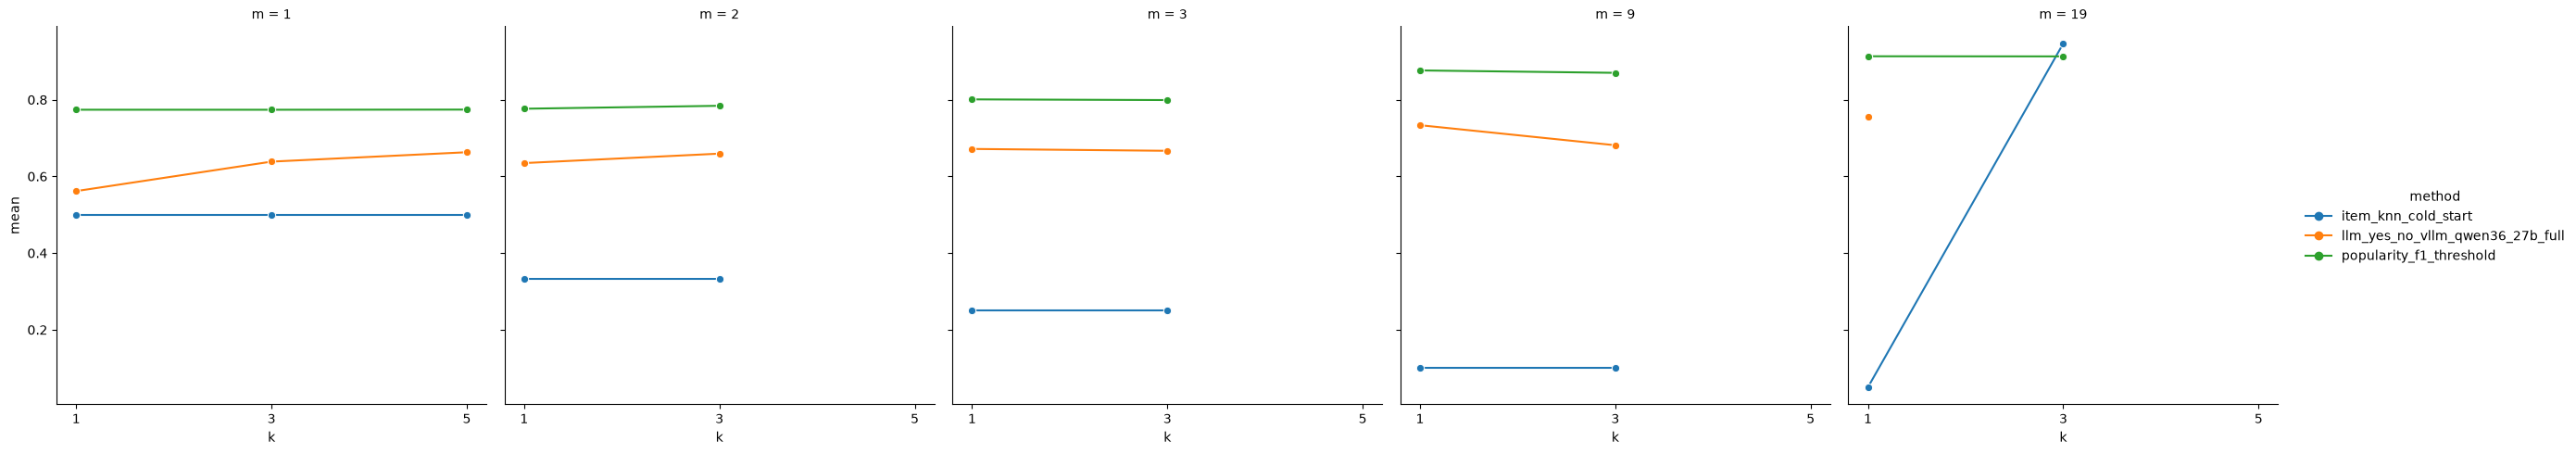

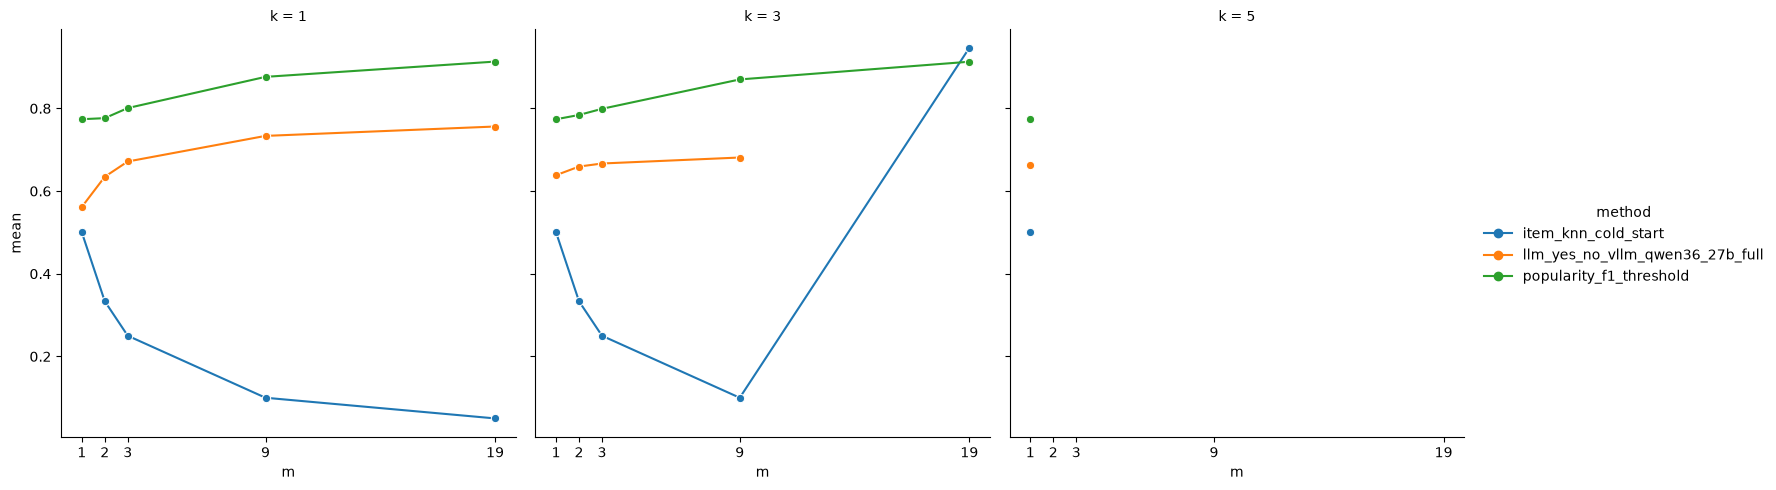

In [17]:
plot_rel_by_k_and_m(pointwise, "test.macro_by_user_group_mean.accuracy")

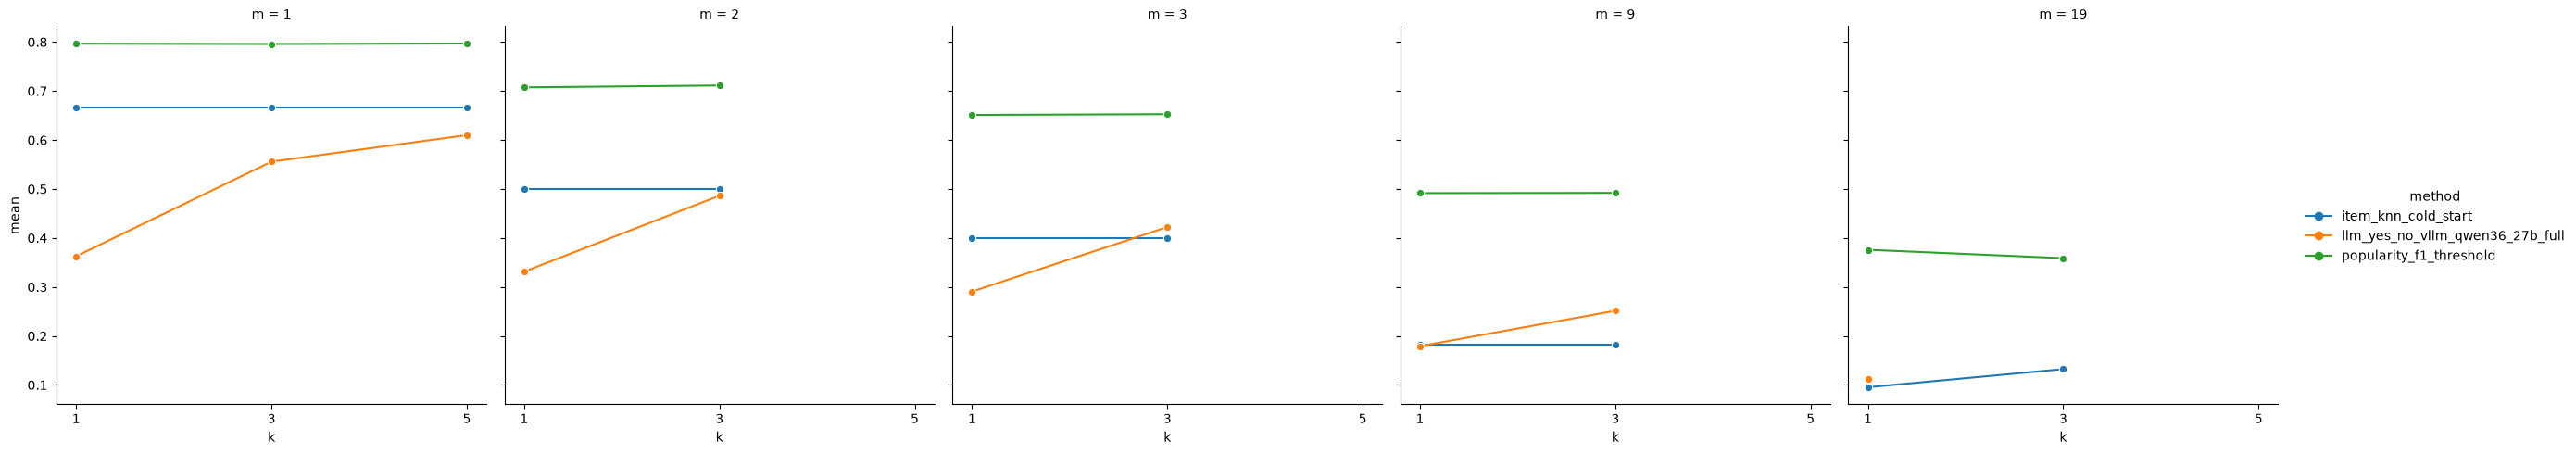

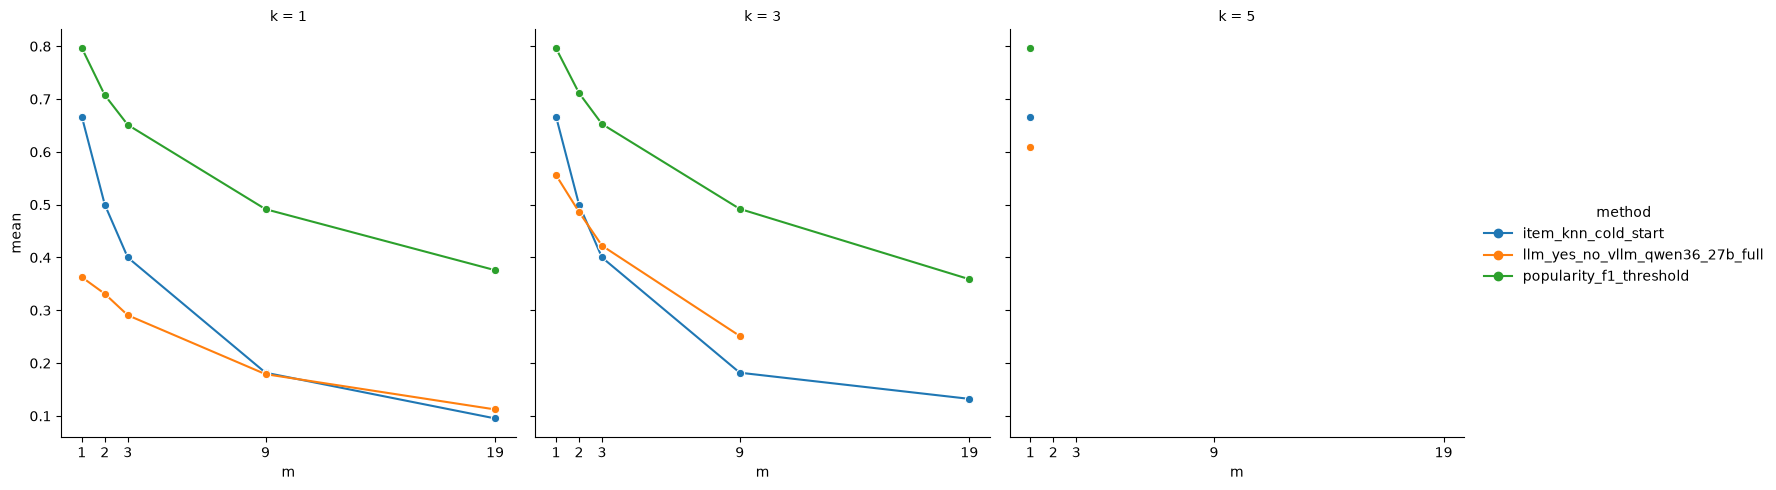

In [18]:
plot_rel_by_k_and_m(pointwise, "test.macro_by_user_group_mean.f1")

In [19]:
[i for i in ranking.columns.tolist() if "test.macro_by_user_group_mean." in i]

['test.macro_by_user_group_mean.accuracy',
 'test.macro_by_user_group_mean.f1',
 'test.macro_by_user_group_mean.n',
 'test.macro_by_user_group_mean.n_groups',
 'test.macro_by_user_group_mean.n_positive',
 'test.macro_by_user_group_mean.n_predicted_positive',
 'test.macro_by_user_group_mean.n_users',
 'test.macro_by_user_group_mean.precision',
 'test.macro_by_user_group_mean.recall',
 'test.macro_by_user_group_mean.groups_with_score_ties',
 'test.macro_by_user_group_mean.groups_with_score_ties_fraction',
 'test.macro_by_user_group_mean.groups_with_size_lte@1',
 'test.macro_by_user_group_mean.groups_with_size_lte@10',
 'test.macro_by_user_group_mean.groups_with_size_lte@3',
 'test.macro_by_user_group_mean.groups_with_size_lte@5',
 'test.macro_by_user_group_mean.groups_without_positive',
 'test.macro_by_user_group_mean.hit_rate@1',
 'test.macro_by_user_group_mean.hit_rate@10',
 'test.macro_by_user_group_mean.hit_rate@3',
 'test.macro_by_user_group_mean.hit_rate@5',
 'test.macro_by_user_gr

In [20]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.hit_rate@1")

method item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k m                                                                  
1 1            0.604253 ± 0.024385             0.557596 ± 0.004655   
  2            0.448372 ± 0.020333             0.409308 ± 0.006772   
  3            0.365713 ± 0.022846             0.324764 ± 0.003323   
  9            0.181608 ± 0.011869             0.149901 ± 0.002579   
  19           0.102513 ± 0.004821             0.080614 ± 0.002619   
3 1            0.698861 ± 0.031233             0.645625 ± 0.001107   
  2            0.556364 ± 0.041738             0.484625 ± 0.002698   
  3            0.481549 ± 0.036019             0.388056 ± 0.004325   
  9            0.270035 ± 0.020235             0.181895 ± 0.002676   
  19                      0.168160                             NaN   
5 1            0.748880 ± 0.029437             0.663110 ± 0.005025   

method   popularity_ranking  
k m                          
1 1     0.893751 ± 0.037233  
  2     0.838459 ± 0.039353  
  3     0.789200 ± 0.053496  
  9     0.616430 ± 0.035120  
  19    0.442567 ± 0.011917  
3 1     0.894351 ± 0.031332  
  2     0.842224 ± 0.029503  
  3     0.785456 ± 0.041930  
  9     0.609580 ± 0.036215  
  19               0.439000  
5 1     0.896233 ± 0.030950

In [21]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.hit_rate@5")

method item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k m                                                                  
1 1            0.988364 ± 0.000614             0.971997 ± 0.004522   
  2            0.927416 ± 0.002193             0.907955 ± 0.004064   
  3            0.841980 ± 0.004033             0.825033 ± 0.009871   
  9            0.499185 ± 0.006562             0.526772 ± 0.006435   
  19           0.292774 ± 0.003172             0.330933 ± 0.004579   
3 1            0.991539 ± 0.000891             0.982843 ± 0.005894   
  2            0.943216 ± 0.004102             0.940707 ± 0.005873   
  3            0.872673 ± 0.007621             0.880769 ± 0.008050   
  9            0.559207 ± 0.010520             0.623490 ± 0.007033   
  19                      0.348276                             NaN   
5 1            0.993320 ± 0.001001             0.987637 ± 0.000773   

method   popularity_ranking  
k m                          
1 1     0.999392 ± 0.000365  
  2     0.996757 ± 0.001580  
  3     0.992824 ± 0.003054  
  9     0.942263 ± 0.005116  
  19    0.799867 ± 0.031335  
3 1     0.999596 ± 0.000469  
  2     0.997004 ± 0.001465  
  3     0.992013 ± 0.001788  
  9     0.939632 ± 0.006391  
  19               0.780033  
5 1     0.999695 ± 0.000106

In [22]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.hit_rate@10")

method item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k m                                                                  
1 1            0.999996 ± 0.000000             0.999979 ± 0.000002   
  2            0.998853 ± 0.000039             0.997569 ± 0.000228   
  3            0.987090 ± 0.000476             0.981333 ± 0.002973   
  9            0.788085 ± 0.002139             0.799354 ± 0.003876   
  19           0.528516 ± 0.002115             0.564688 ± 0.004045   
3 1            0.999997 ± 0.000000             0.999959 ± 0.000015   
  2            0.999107 ± 0.000055             0.998312 ± 0.000455   
  3            0.989641 ± 0.000505             0.987061 ± 0.002392   
  9            0.813607 ± 0.002411             0.858179 ± 0.005551   
  19                      0.565517                             NaN   
5 1            0.999998 ± 0.000000             0.999956 ± 0.000012   

method   popularity_ranking  
k m                          
1 1     1.000000 ± 0.000000  
  2     1.000000 ± 0.000000  
  3     0.999861 ± 0.000121  
  9     0.992258 ± 0.002428  
  19    0.939100 ± 0.015773  
3 1     1.000000 ± 0.000000  
  2     1.000000 ± 0.000000  
  3     0.999579 ± 0.000161  
  9     0.992709 ± 0.001397  
  19               0.931433  
5 1     1.000000 ± 0.000000

In [23]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.ndcg@1")

method item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k m                                                                  
1 1            0.604253 ± 0.024385             0.557596 ± 0.004655   
  2            0.448372 ± 0.020333             0.409308 ± 0.006772   
  3            0.365713 ± 0.022846             0.324764 ± 0.003323   
  9            0.181608 ± 0.011869             0.149901 ± 0.002579   
  19           0.102513 ± 0.004821             0.080614 ± 0.002619   
3 1            0.698861 ± 0.031233             0.645625 ± 0.001107   
  2            0.556364 ± 0.041738             0.484625 ± 0.002698   
  3            0.481549 ± 0.036019             0.388056 ± 0.004325   
  9            0.270035 ± 0.020235             0.181895 ± 0.002676   
  19                      0.168160                             NaN   
5 1            0.748880 ± 0.029437             0.663110 ± 0.005025   

method   popularity_ranking  
k m                          
1 1     0.893751 ± 0.037233  
  2     0.838459 ± 0.039353  
  3     0.789200 ± 0.053496  
  9     0.616430 ± 0.035120  
  19    0.442567 ± 0.011917  
3 1     0.894351 ± 0.031332  
  2     0.842224 ± 0.029503  
  3     0.785456 ± 0.041930  
  9     0.609580 ± 0.036215  
  19               0.439000  
5 1     0.896233 ± 0.030950

In [24]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.ndcg@5")

method item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k m                                                                  
1 1            0.556031 ± 0.010358             0.572201 ± 0.006162   
  2            0.389722 ± 0.007242             0.416277 ± 0.012170   
  3            0.305409 ± 0.007006             0.328272 ± 0.012644   
  9            0.231973 ± 0.004194             0.247483 ± 0.004584   
  19           0.195423 ± 0.003887             0.205146 ± 0.003509   
3 1            0.609141 ± 0.020567             0.653058 ± 0.006463   
  2            0.439760 ± 0.016184             0.486396 ± 0.008849   
  3            0.356157 ± 0.014892             0.387840 ± 0.006813   
  9            0.290388 ± 0.010057             0.304451 ± 0.007088   
  19                      0.256766                             NaN   
5 1            0.643756 ± 0.024015             0.670984 ± 0.003977   

method   popularity_ranking  
k m                          
1 1     0.881236 ± 0.020773  
  2     0.780171 ± 0.018645  
  3     0.702038 ± 0.020007  
  9     0.692063 ± 0.012958  
  19    0.630912 ± 0.022195  
3 1     0.880632 ± 0.019888  
  2     0.780364 ± 0.015411  
  3     0.700342 ± 0.018444  
  9     0.692419 ± 0.011479  
  19               0.615839  
5 1     0.879746 ± 0.018775

In [25]:
make_mean_std_pivot(ranking, "test.macro_by_user_group_mean.ndcg@10")

method item_knn_cold_start_ranking llm_yes_no_vllm_qwen36_27b_full  \
k m                                                                  
1 1            0.549410 ± 0.007286             0.577182 ± 0.012015   
  2            0.505280 ± 0.005918             0.536422 ± 0.012923   
  3            0.434628 ± 0.006782             0.464205 ± 0.011881   
  9            0.325590 ± 0.002721             0.341304 ± 0.005356   
  19           0.270629 ± 0.003550             0.279978 ± 0.003283   
3 1            0.580268 ± 0.009238             0.645445 ± 0.010478   
  2            0.543935 ± 0.010974             0.608978 ± 0.010087   
  3            0.479565 ± 0.012581             0.534875 ± 0.006331   
  9            0.377789 ± 0.008166             0.403063 ± 0.006492   
  19                      0.326071                             NaN   
5 1            0.599936 ± 0.012392             0.663820 ± 0.004791   

method   popularity_ranking  
k m                          
1 1     0.837360 ± 0.013539  
  2     0.868417 ± 0.010753  
  3     0.835445 ± 0.013647  
  9     0.753864 ± 0.009128  
  19    0.676178 ± 0.017343  
3 1     0.837238 ± 0.013114  
  2     0.869909 ± 0.007866  
  3     0.836031 ± 0.011933  
  9     0.753000 ± 0.007887  
  19               0.665025  
5 1     0.837842 ± 0.014023

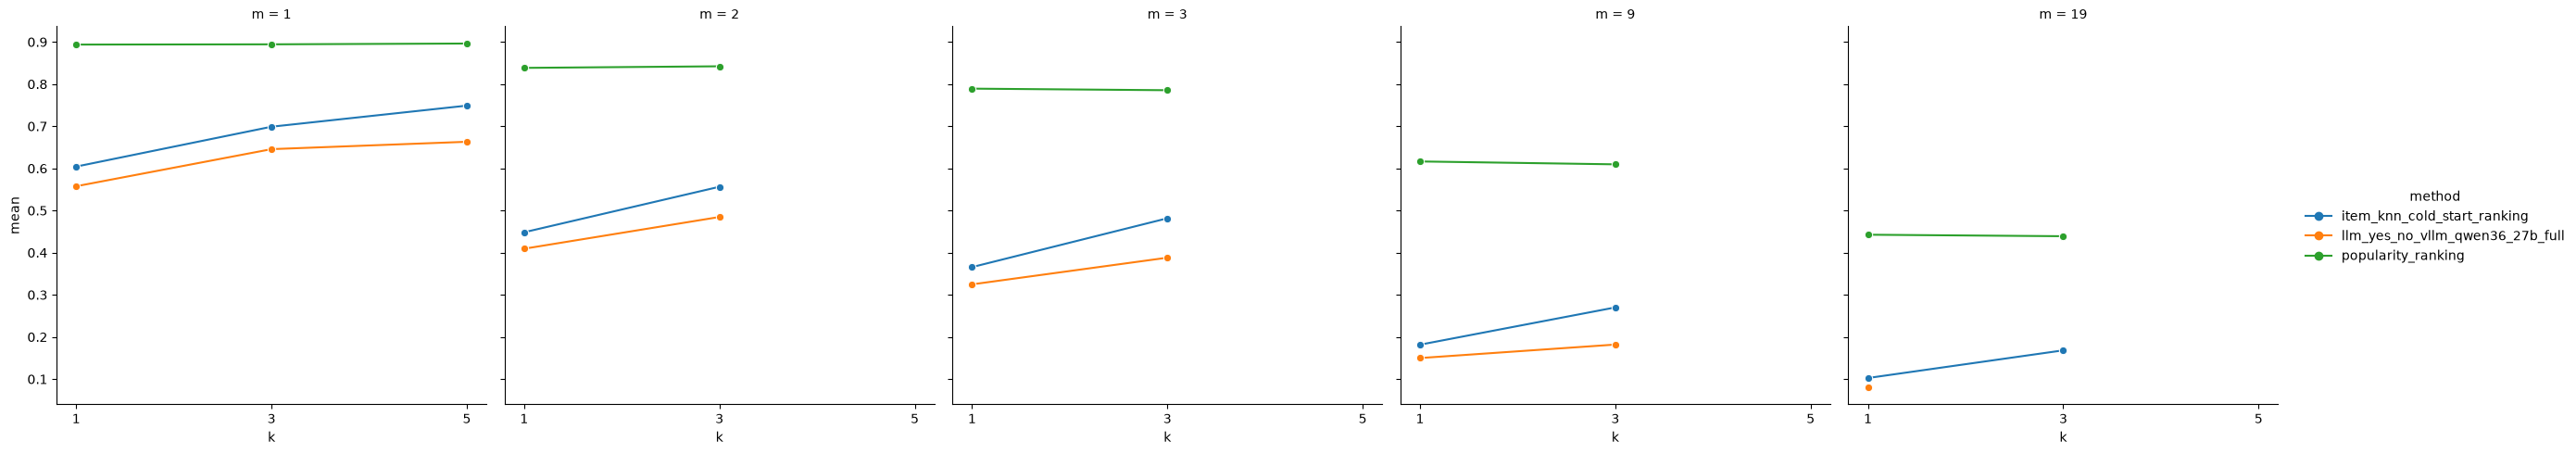

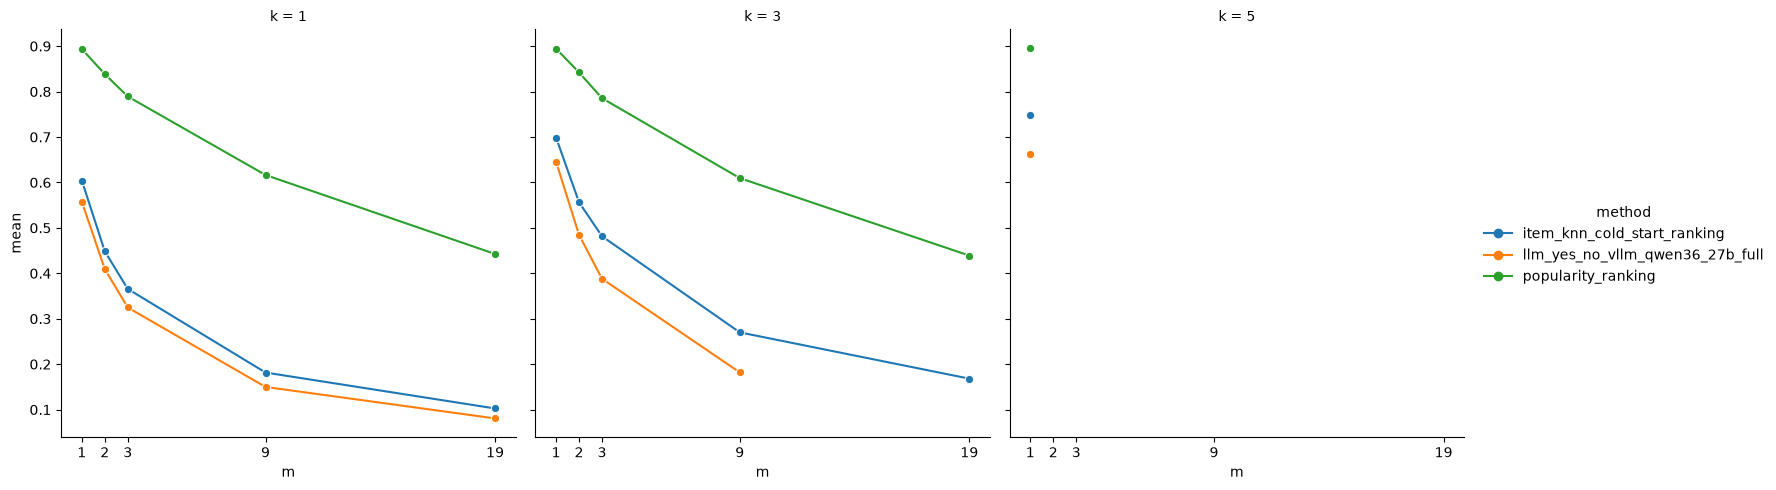

In [26]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.ndcg@1")

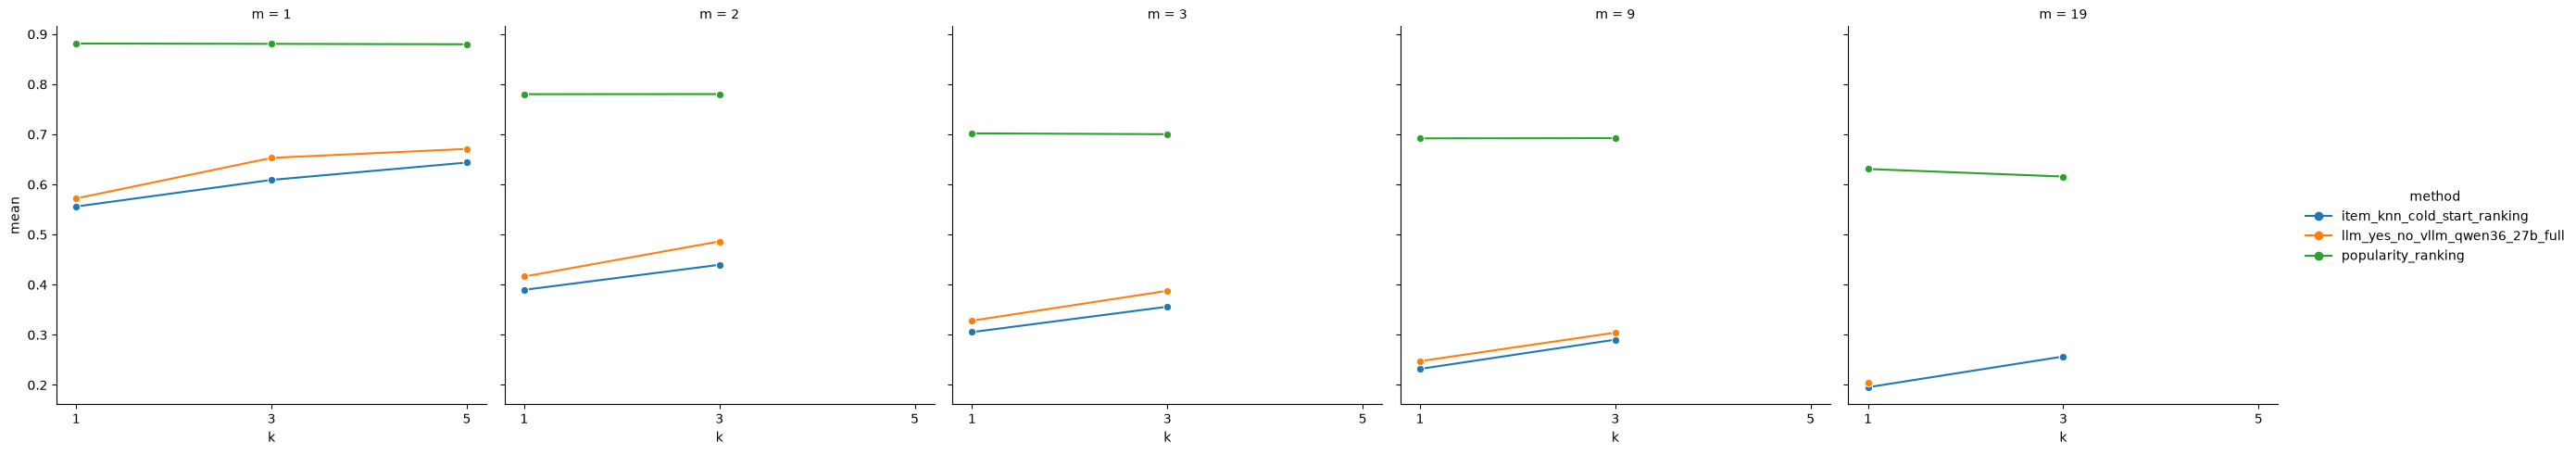

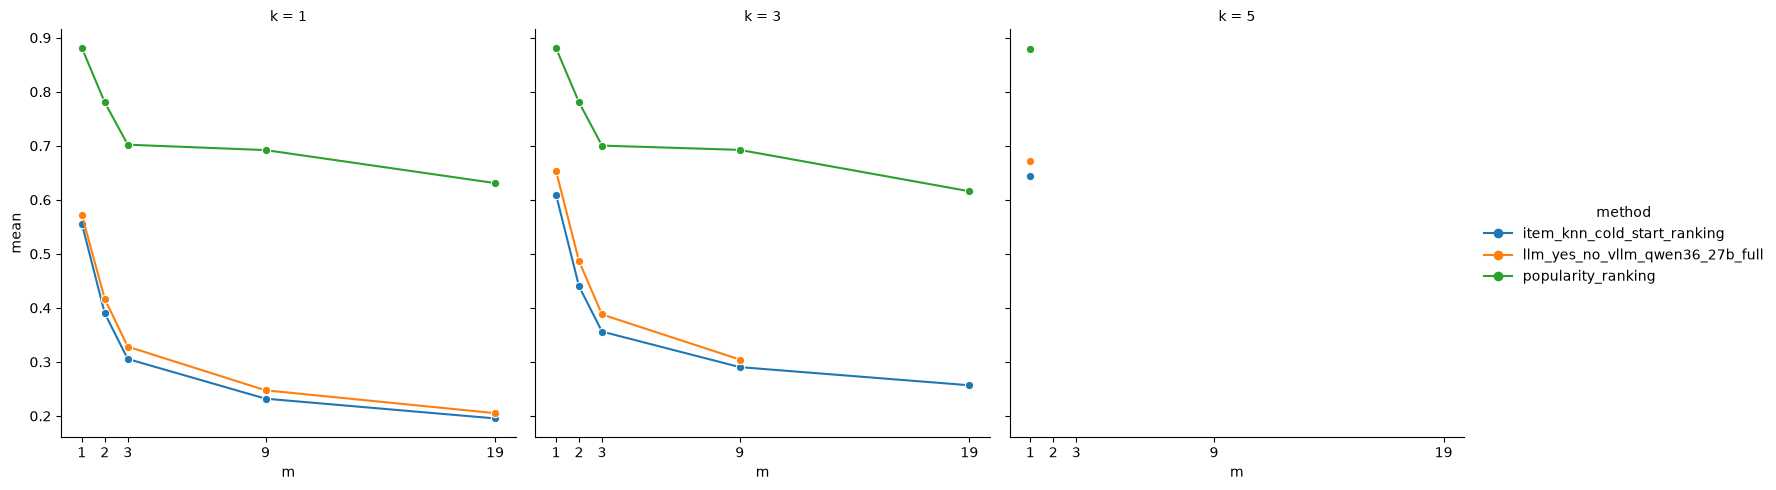

In [27]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.ndcg@5")

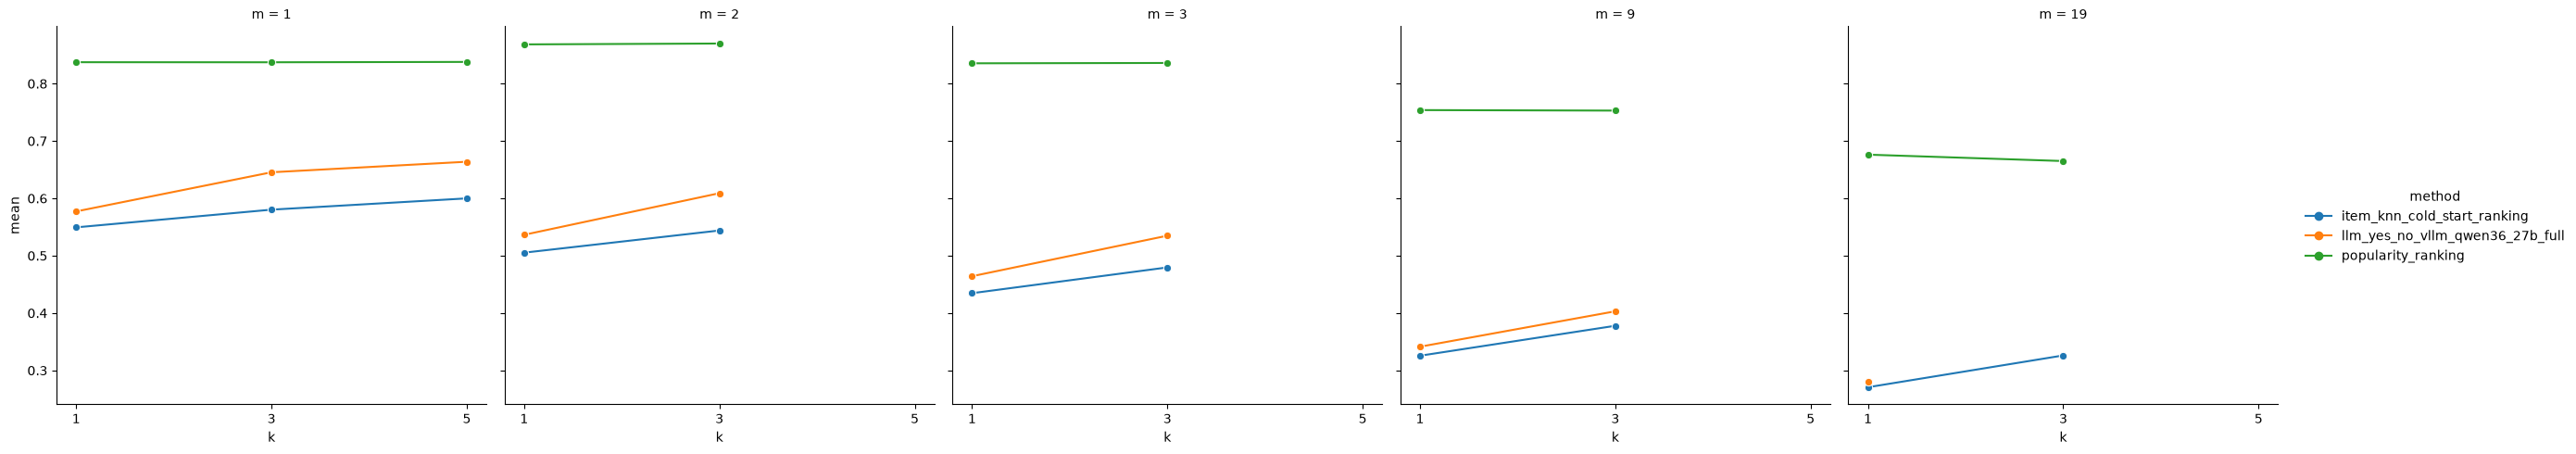

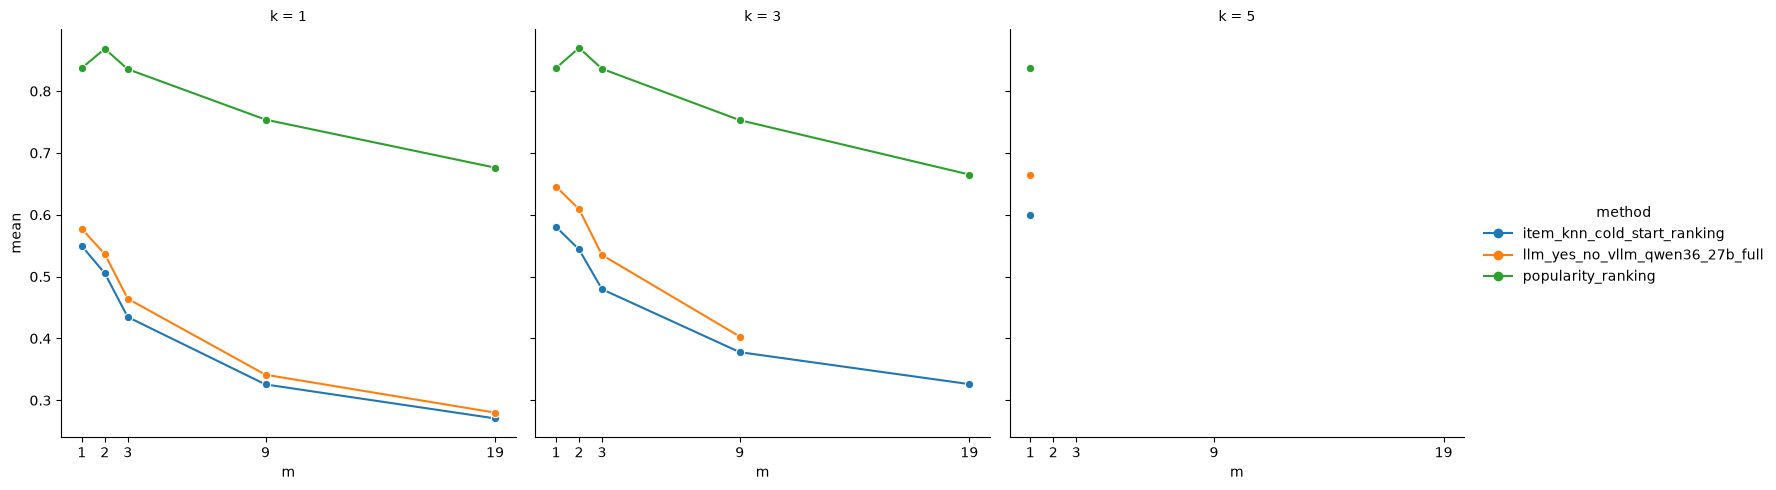

In [28]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.ndcg@10")

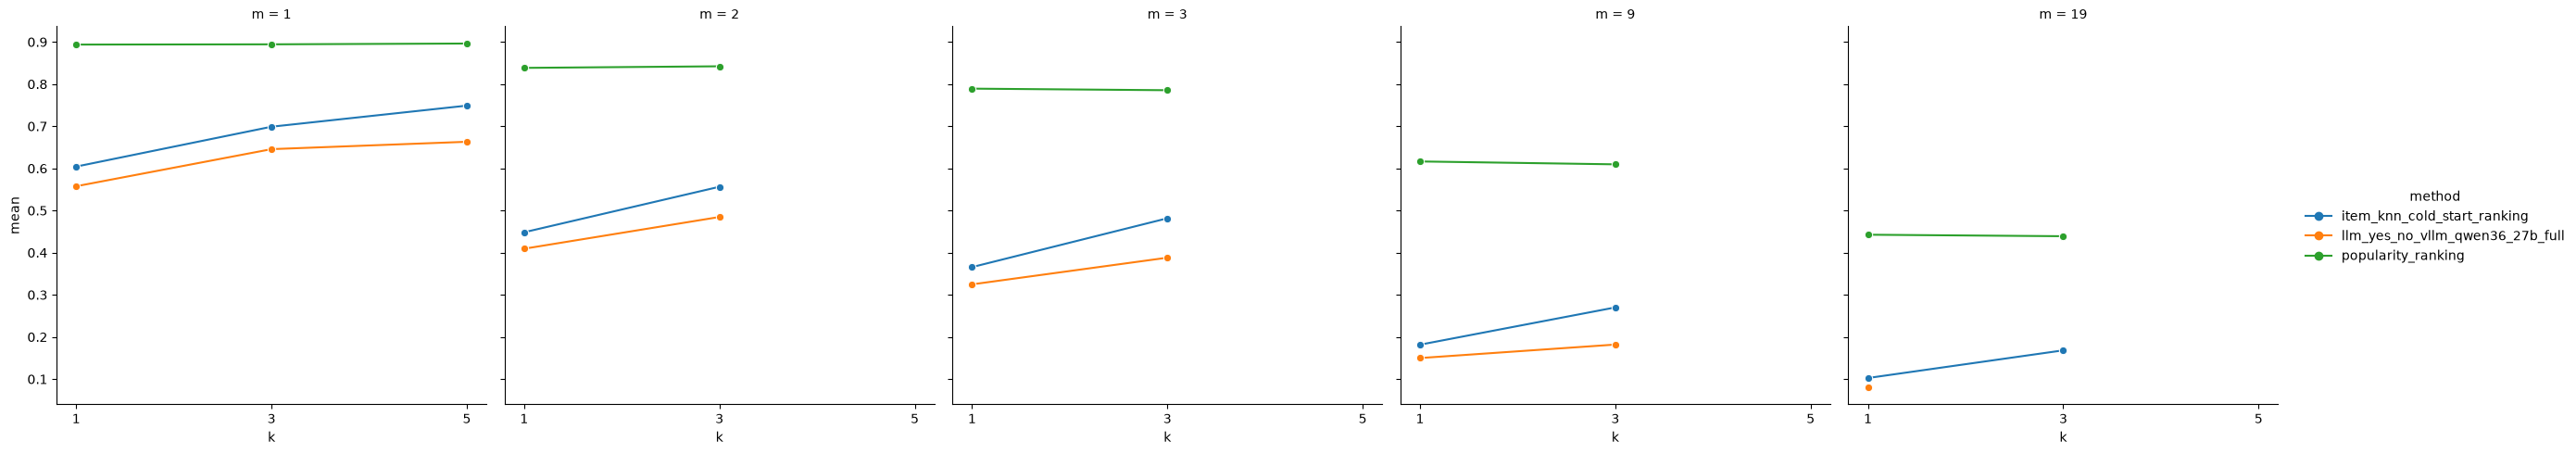

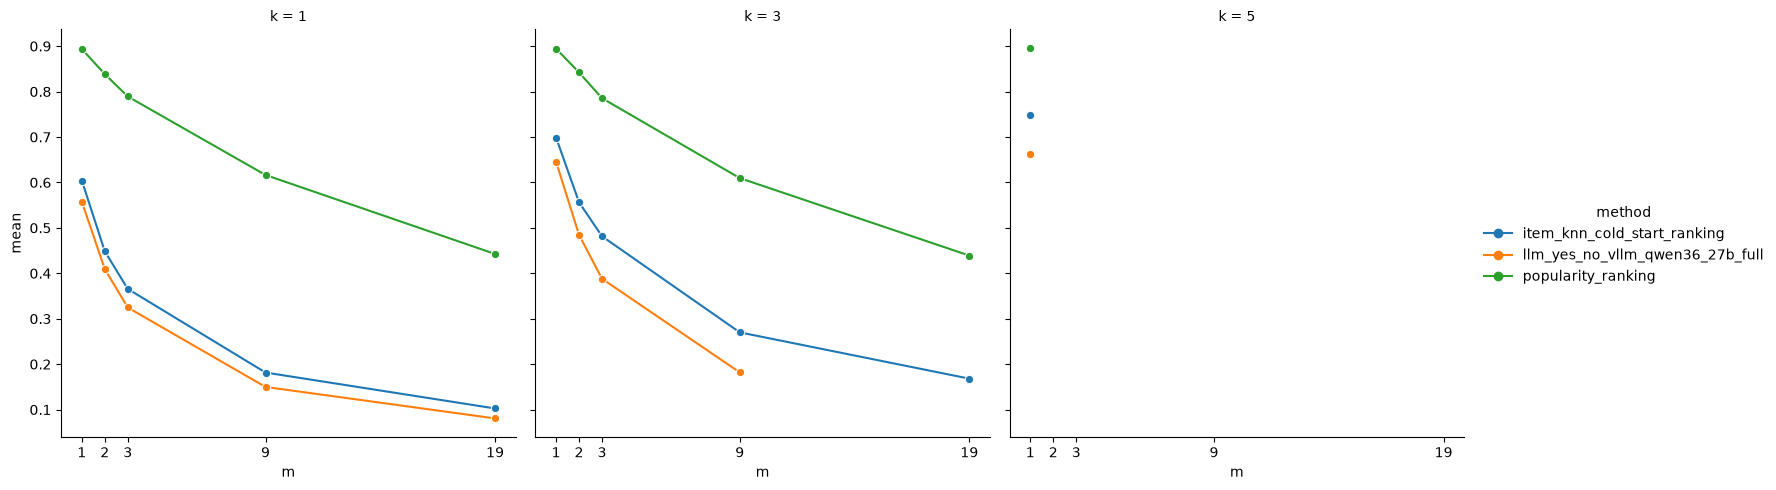

In [29]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.hit_rate@1")

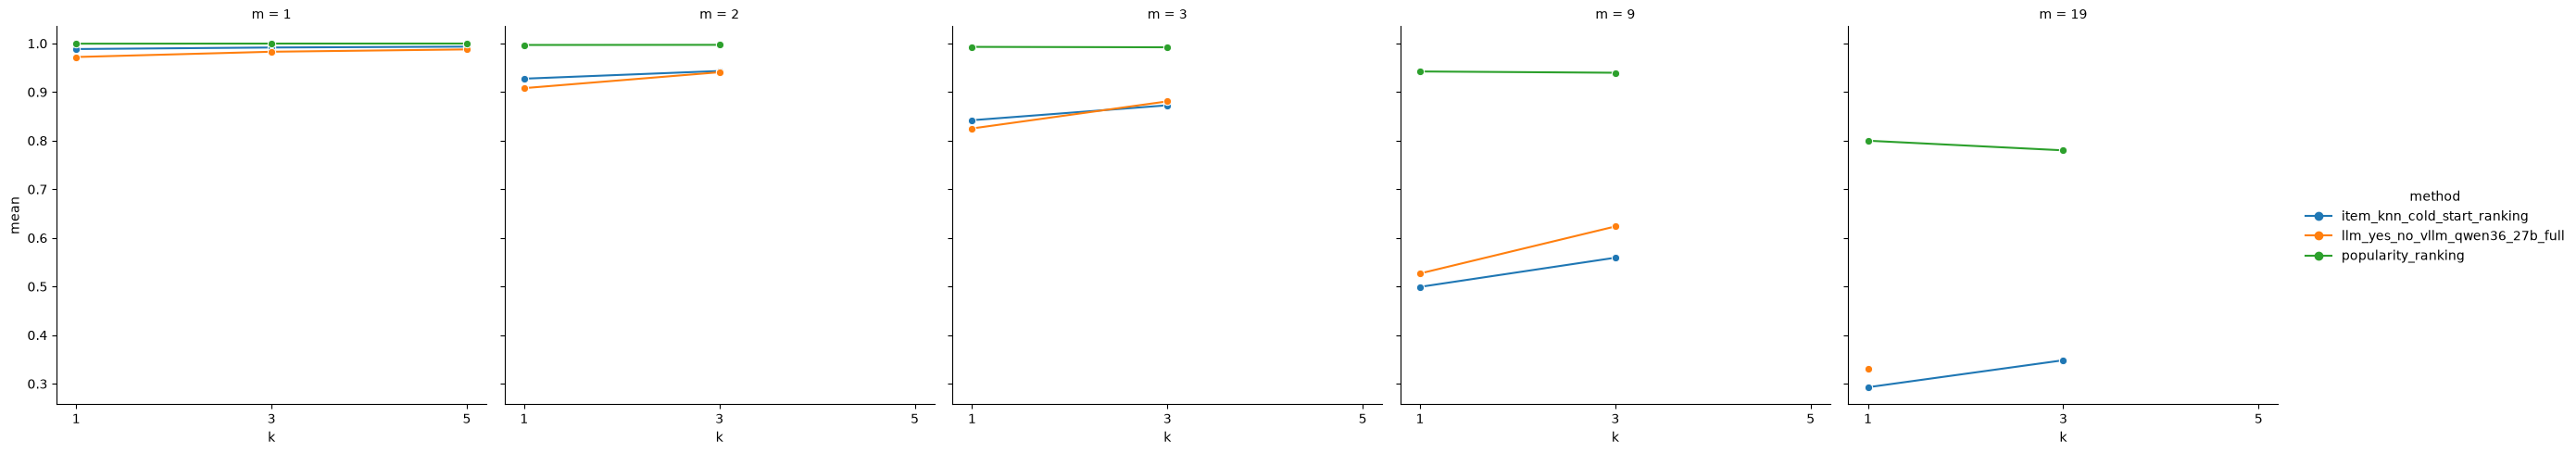

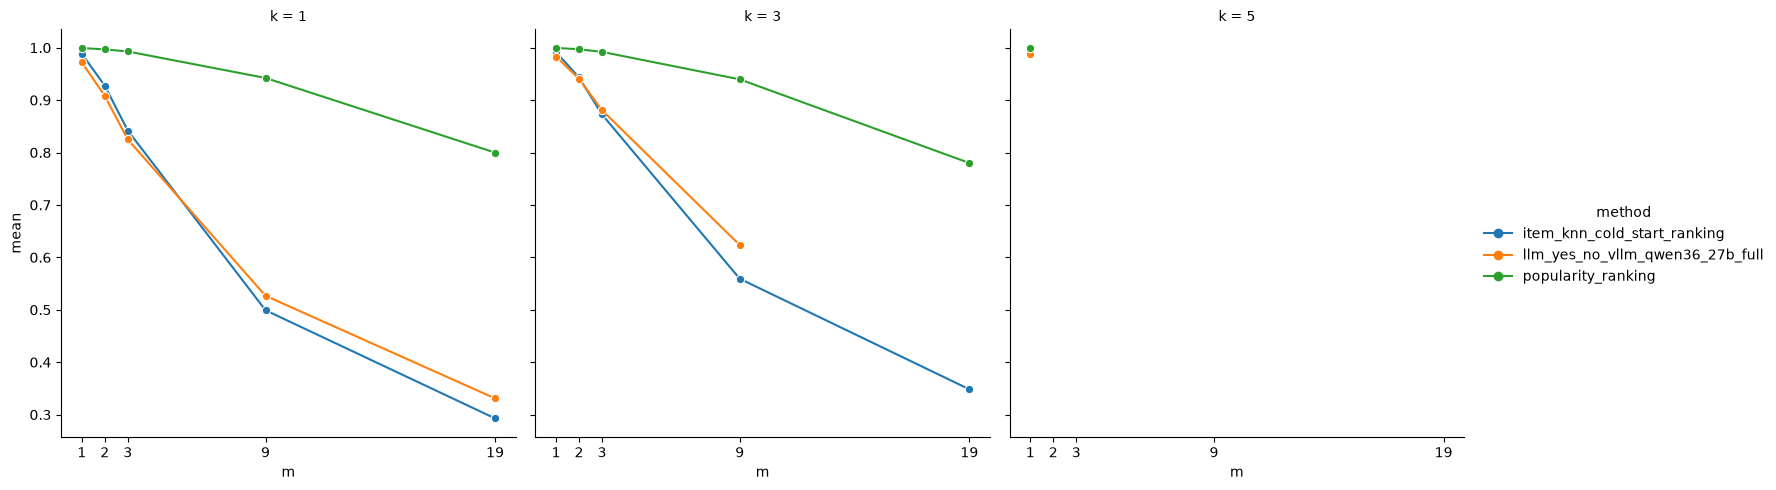

In [30]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.hit_rate@5")

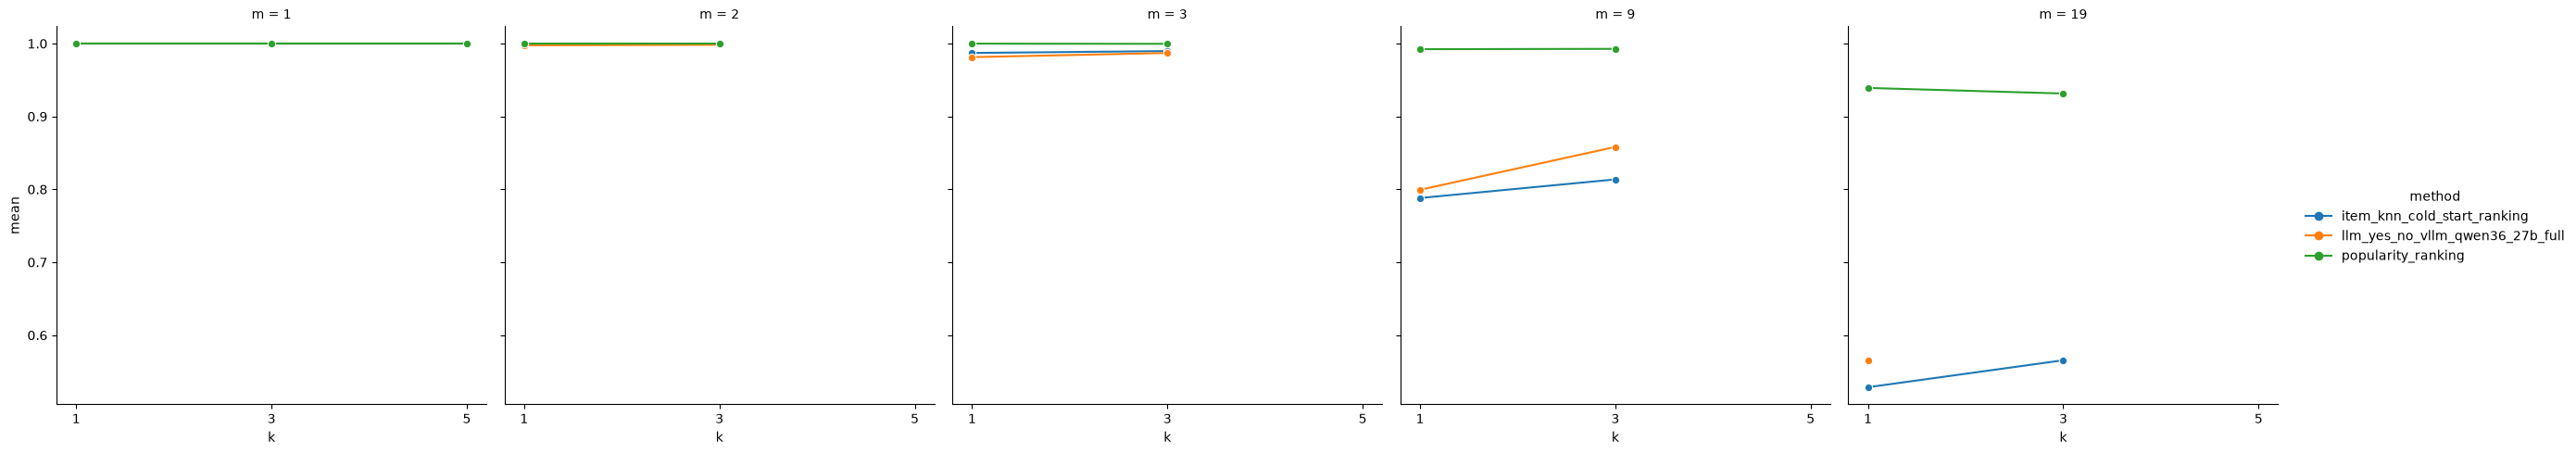

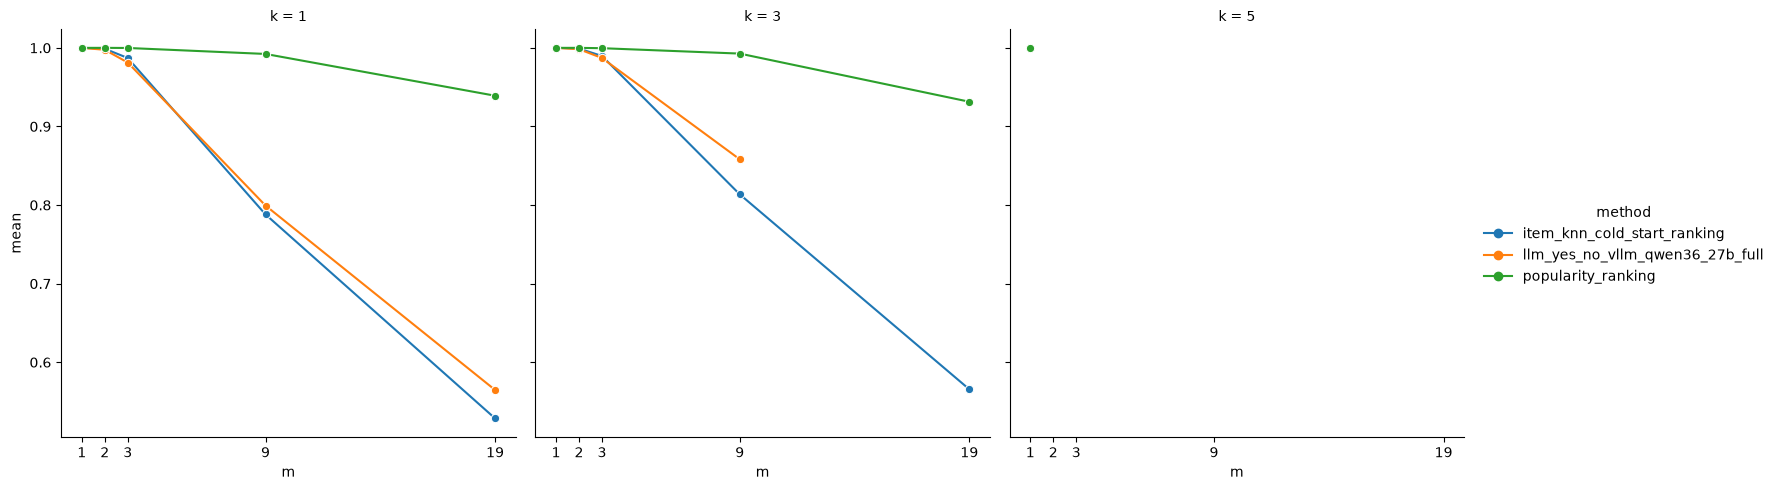

In [31]:
plot_rel_by_k_and_m(ranking, "test.macro_by_user_group_mean.hit_rate@10")

# ItemKNN inspect

In [33]:
import sys

sys.path.append("/llm_storage/beyond-click-sim")

from pathlib import Path

import pandas as pd

from beyond_click_sim.evaluation import (
    apply_threshold,
    find_best_user_group_threshold,
)
from beyond_click_sim.scorers import ColdItemKNNScorer
from beyond_click_sim.tasks import split_xy
from runners.in_distribution.cold_start.task_builders import build_cold_start_task
from runners.in_distribution.interaction_prediction.methods.common import task_xy

# Same defaults as runners/in_distribution/cold_start/task_builders.py
SEED = 0
M = 1          # negative_ratio; use 19 for 1 pos + 19 negs per group
K_VALUES = [1, 3]

def run_item_knn_manual(k: int):
    task = build_cold_start_task(
        dataset_name="ml-1m",
        k=k,
        negative_ratio=M,
        seed=SEED,
        max_eval_users=1000,
        max_groups_per_user=5,
        group_offset=SEED * 5,   # same as EVAL1000_CG5_TASK_BUILDERS
    )

    xy = task_xy(task)
    X_train, y_train = xy["train"]
    X_val, y_val = xy["val"]
    X_test, y_test = xy["test"]

    X_history, y_history = split_xy(
        task.online_session_history,
        target_column=task.schema.target_column,
    )

    scorer = (
        ColdItemKNNScorer(n_neighbors=20, aggregation="mean")
        .fit_train(X_train, y_train)   # warm item-item similarity
        .fit(X_history, y_history)     # cold user k-item profiles
    )

    val_scores = scorer.score(X_val)
    test_scores = scorer.score(X_test)

    threshold_sel = find_best_user_group_threshold(
        y_val,
        val_scores,
        X_val[task.schema.candidate_group_column],
        X_val["user_id"],
        metric="f1",
    )
    threshold = float(threshold_sel["threshold"])

    val_pred = apply_threshold(val_scores, threshold)
    test_pred = apply_threshold(test_scores, threshold)

    return {
        "k": k,
        "task": task,
        "scorer": scorer,
        "X_val": X_val,
        "y_val": y_val,
        "val_scores": val_scores,
        "test_scores": test_scores,
        "threshold": threshold,
        "val_pred": val_pred,
        "test_pred": test_pred,
    }

results = {k: run_item_knn_manual(k) for k in K_VALUES}

In [45]:
(results[1]["test_scores"] == 0).sum() / results[1]["test_scores"].shape[0]

np.float64(0.9718190344334777)